Cell 1: Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Load processed data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_val = pd.read_csv("../data/processed/X_val.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_val = pd.read_csv("../data/processed/y_val.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"✅ Data Loaded:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_val:   {y_val.shape}")
print(f"   y_test:  {y_test.shape}")

✅ Data Loaded:
   X_train: (8345, 109)
   X_val:   (1789, 109)
   X_test:  (1789, 109)
   y_train: (8345,)
   y_val:   (1789,)
   y_test:  (1789,)


Cell 2: Evaluation Functions

In [2]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name="Model"):
    """Train and evaluate a model, return metrics and predictions"""
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict (log scale)
    y_train_pred_log = model.predict(X_train)
    y_val_pred_log = model.predict(X_val)
    y_test_pred_log = model.predict(X_test)
    
    # Convert back to original price ($)
    y_train_pred = np.expm1(y_train_pred_log)
    y_val_pred = np.expm1(y_val_pred_log)
    y_test_pred = np.expm1(y_test_pred_log)
    
    y_train_orig = np.expm1(y_train)
    y_val_orig = np.expm1(y_val)
    y_test_orig = np.expm1(y_test)
    
    # Metrics
    metrics = {
        'Model': model_name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train_orig, y_train_pred)),
        'Val RMSE': np.sqrt(mean_squared_error(y_val_orig, y_val_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_orig, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train_orig, y_train_pred),
        'Val MAE': mean_absolute_error(y_val_orig, y_val_pred),
        'Test MAE': mean_absolute_error(y_test_orig, y_test_pred),
        'Train R²': r2_score(y_train_orig, y_train_pred),
        'Val R²': r2_score(y_val_orig, y_val_pred),
        'Test R²': r2_score(y_test_orig, y_test_pred),
    }
    
    return metrics, y_test_pred, y_test_orig, model

def print_metrics(metrics):
    """Pretty print metrics"""
    print(f"\n{'='*60}")
    print(f"📊 {metrics['Model']}")
    print(f"{'='*60}")
    print(f"  Train RMSE: ${metrics['Train RMSE']:.2f} | MAE: ${metrics['Train MAE']:.2f} | R²: {metrics['Train R²']:.3f}")
    print(f"  Val   RMSE: ${metrics['Val RMSE']:.2f} | MAE: ${metrics['Val MAE']:.2f} | R²: {metrics['Val R²']:.3f}")
    print(f"  Test  RMSE: ${metrics['Test RMSE']:.2f} | MAE: ${metrics['Test MAE']:.2f} | R²: {metrics['Test R²']:.3f}")

Cell 3: Baseline - Mean Predictor

In [3]:
# Mean predictor (always predicts the mean log price)
class MeanPredictor:
    def fit(self, X, y):
        self.mean = np.mean(y)
    def predict(self, X):
        return np.full(X.shape[0], self.mean)

mean_model = MeanPredictor()
metrics_mean, _, _, _ = evaluate_model(mean_model, X_train, y_train, X_val, y_val, X_test, y_test, "Mean Predictor")
print_metrics(metrics_mean)

all_results = [metrics_mean]


📊 Mean Predictor
  Train RMSE: $183.95 | MAE: $105.13 | R²: -0.068
  Val   RMSE: $182.30 | MAE: $105.45 | R²: -0.071
  Test  RMSE: $180.26 | MAE: $106.11 | R²: -0.073


Cell 4: Linear Regression

In [4]:
lr = LinearRegression()
metrics_lr, y_pred_lr, y_test_orig, model_lr = evaluate_model(
    lr, X_train, y_train, X_val, y_val, X_test, y_test, "Linear Regression"
)
print_metrics(metrics_lr)
all_results.append(metrics_lr)


📊 Linear Regression
  Train RMSE: $112.35 | MAE: $58.99 | R²: 0.601
  Val   RMSE: $120.69 | MAE: $61.27 | R²: 0.531
  Test  RMSE: $113.75 | MAE: $60.62 | R²: 0.573


Cell 5: Ridge Regression

In [5]:
ridge = Ridge(alpha=1.0)
metrics_ridge, _, _, _ = evaluate_model(
    ridge, X_train, y_train, X_val, y_val, X_test, y_test, "Ridge Regression"
)
print_metrics(metrics_ridge)
all_results.append(metrics_ridge)


📊 Ridge Regression
  Train RMSE: $112.59 | MAE: $59.06 | R²: 0.600
  Val   RMSE: $120.65 | MAE: $61.27 | R²: 0.531
  Test  RMSE: $113.75 | MAE: $60.59 | R²: 0.573


Cell 6: Random Forest

In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
metrics_rf, y_pred_rf, _, model_rf = evaluate_model(
    rf, X_train, y_train, X_val, y_val, X_test, y_test, "Random Forest"
)
print_metrics(metrics_rf)
all_results.append(metrics_rf)


📊 Random Forest
  Train RMSE: $70.66 | MAE: $29.97 | R²: 0.842
  Val   RMSE: $100.16 | MAE: $48.02 | R²: 0.677
  Test  RMSE: $98.03 | MAE: $48.37 | R²: 0.683


Cell 7: XGBoost

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
metrics_xgb, y_pred_xgb, _, model_xgb = evaluate_model(
    xgb_model, X_train, y_train, X_val, y_val, X_test, y_test, "XGBoost"
)
print_metrics(metrics_xgb)
all_results.append(metrics_xgb)


📊 XGBoost
  Train RMSE: $24.19 | MAE: $12.78 | R²: 0.982
  Val   RMSE: $86.38 | MAE: $42.51 | R²: 0.760
  Test  RMSE: $88.97 | MAE: $43.34 | R²: 0.739


Cell 8: LightGBM

In [8]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
metrics_lgb, y_pred_lgb, _, model_lgb = evaluate_model(
    lgb_model, X_train, y_train, X_val, y_val, X_test, y_test, "LightGBM"
)
print_metrics(metrics_lgb)
all_results.append(metrics_lgb)


📊 LightGBM
  Train RMSE: $49.33 | MAE: $24.80 | R²: 0.923
  Val   RMSE: $90.25 | MAE: $44.02 | R²: 0.738
  Test  RMSE: $91.34 | MAE: $45.00 | R²: 0.724


Cell 9: Gradient Boosting

In [9]:
gbm = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
metrics_gbm, _, _, _ = evaluate_model(
    gbm, X_train, y_train, X_val, y_val, X_test, y_test, "Gradient Boosting"
)
print_metrics(metrics_gbm)
all_results.append(metrics_gbm)


📊 Gradient Boosting
  Train RMSE: $55.48 | MAE: $30.24 | R²: 0.903
  Val   RMSE: $86.25 | MAE: $44.04 | R²: 0.760
  Test  RMSE: $92.23 | MAE: $45.84 | R²: 0.719


Cell 10: Ensemble - Voting Regressor

In [10]:
# Ensemble of XGBoost + LightGBM
ensemble = VotingRegressor([
    ('xgb', model_xgb),
    ('lgb', model_lgb),
    ('rf', model_rf)
])

ensemble.fit(X_train, y_train)

# Predict
y_ens_pred_log = ensemble.predict(X_test)
y_ens_pred = np.expm1(y_ens_pred_log)

metrics_ensemble = {
    'Model': 'Ensemble (XGB+LGB+RF)',
    'Test RMSE': np.sqrt(mean_squared_error(y_test_orig, y_ens_pred)),
    'Test MAE': mean_absolute_error(y_test_orig, y_ens_pred),
    'Test R²': r2_score(y_test_orig, y_ens_pred),
}

print(f"\n{'='*60}")
print(f"📊 Ensemble (XGBoost + LightGBM + Random Forest)")
print(f"{'='*60}")
print(f"  Test  RMSE: ${metrics_ensemble['Test RMSE']:.2f} | MAE: ${metrics_ensemble['Test MAE']:.2f} | R²: {metrics_ensemble['Test R²']:.3f}")

all_results.append(metrics_ensemble)


📊 Ensemble (XGBoost + LightGBM + Random Forest)
  Test  RMSE: $91.17 | MAE: $44.32 | R²: 0.725


Cell 11: Model Comparison

In [11]:
# Create comparison dataframe
results_df = pd.DataFrame(all_results)
results_df.set_index('Model', inplace=True)

# Sort by Test R²
results_df = results_df.sort_values('Test R²', ascending=False)

print("="*60)
print("🏆 MODEL COMPARISON (Sorted by Test R²)")
print("="*60)
print(results_df[['Test RMSE', 'Test MAE', 'Test R²']].to_string())

# Identify best model
best_model_name = results_df.index[0]
best_r2 = results_df.iloc[0]['Test R²']
best_rmse = results_df.iloc[0]['Test RMSE']
best_mae = results_df.iloc[0]['Test MAE']

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"  R² Score: {best_r2:.3f}")
print(f"  RMSE: ${best_rmse:.2f}")
print(f"  MAE: ${best_mae:.2f}")

🏆 MODEL COMPARISON (Sorted by Test R²)
                        Test RMSE    Test MAE   Test R²
Model                                                  
XGBoost                 88.970304   43.342605  0.738509
Ensemble (XGB+LGB+RF)   91.167944   44.316423  0.725432
LightGBM                91.344332   44.997625  0.724368
Gradient Boosting       92.226705   45.836620  0.719018
Random Forest           98.026716   48.367787  0.682565
Ridge Regression       113.748877   60.586240  0.572575
Linear Regression      113.752057   60.622156  0.572551
Mean Predictor         180.258940  106.114416 -0.073395

🏆 BEST MODEL: XGBoost
  R² Score: 0.739
  RMSE: $88.97
  MAE: $43.34


Cell 12: Visualization - Predictions vs Actual

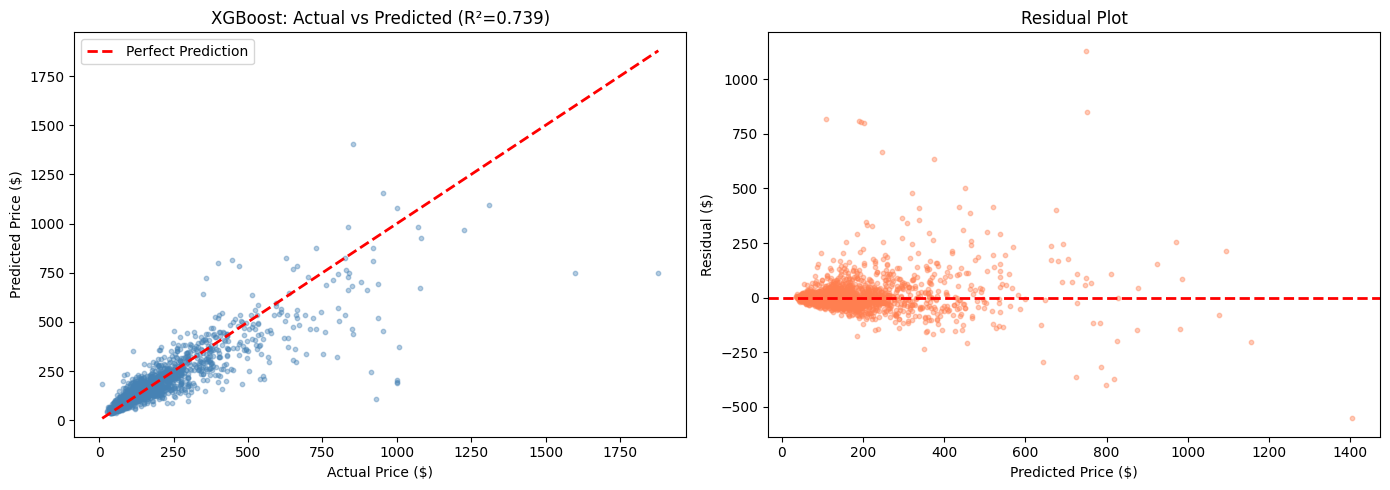

✅ Plot saved as 'model_predictions.png'


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted (using best model - XGBoost)
axes[0].scatter(y_test_orig, y_pred_xgb, alpha=0.4, s=10, color='steelblue')
axes[0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'XGBoost: Actual vs Predicted (R²={best_r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_test_orig - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals, alpha=0.4, s=10, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as 'model_predictions.png'")

Cell 13: Feature Importance (XGBoost)

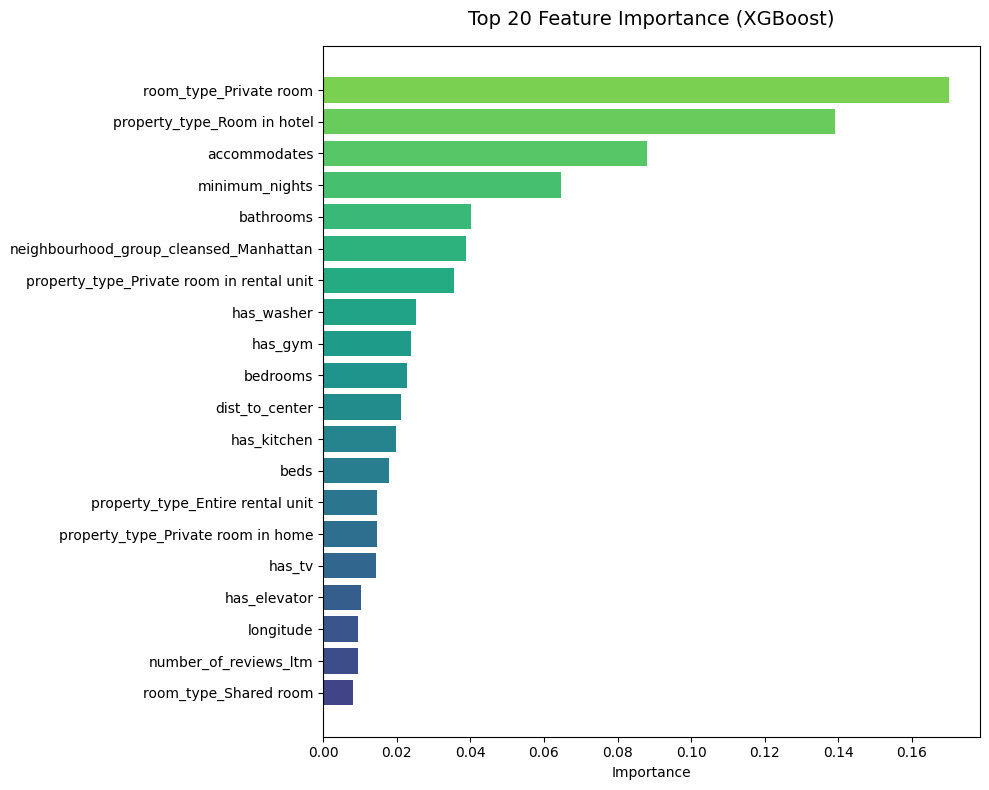

✅ Important features saved as 'feature_importance.png'

🔝 Top 10 Features:
   1. room_type_Private room: 0.1700
   2. property_type_Room in hotel: 0.1390
   3. accommodates: 0.0881
   4. minimum_nights: 0.0647
   5. bathrooms: 0.0402
   6. neighbourhood_group_cleansed_Manhattan: 0.0389
   7. property_type_Private room in rental unit: 0.0357
   8. has_washer: 0.0252
   9. has_gym: 0.0237
   10. bedrooms: 0.0228


In [13]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance_df.head(20)
colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, 20))

ax.barh(range(20), top_features['importance'].values, color=colors)
ax.set_yticks(range(20))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importance (XGBoost)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Important features saved as 'feature_importance.png'")

# Print top 10
print("\n🔝 Top 10 Features:")
for i, (feature, imp) in enumerate(zip(top_features['feature'].head(10).values, 
                                         top_features['importance'].head(10).values)):
    print(f"   {i+1}. {feature}: {imp:.4f}")

Cell 14: Save Best Model

In [14]:
# Save best model
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# Save XGBoost (likely best)
joblib.dump(model_xgb, f"{models_dir}/xgboost_model.pkl")
print(f"✅ XGBoost model saved to {models_dir}/xgboost_model.pkl")

# Also save LightGBM and ensemble
joblib.dump(model_lgb, f"{models_dir}/lightgbm_model.pkl")
joblib.dump(ensemble, f"{models_dir}/ensemble_model.pkl")

# Save feature list
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, f"{models_dir}/feature_names.pkl")
print(f"✅ Feature names saved to {models_dir}/feature_names.pkl")

print(f"\n📁 Models saved: xgboost_model.pkl, lightgbm_model.pkl, ensemble_model.pkl")

✅ XGBoost model saved to ../models/xgboost_model.pkl
✅ Feature names saved to ../models/feature_names.pkl

📁 Models saved: xgboost_model.pkl, lightgbm_model.pkl, ensemble_model.pkl


Cell 15: Phase 4 Summary

In [15]:
print("="*65)
print("🤖 PHASE 4 COMPLETE - MODEL TRAINING SUMMARY")
print("="*65)

print(f"\n📊 Models Trained:")
models_list = ['Mean Predictor', 'Linear Regression', 'Ridge Regression', 
               'Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting', 'Ensemble']
for m in models_list:
    if m in results_df.index:
        r2 = results_df.loc[m, 'Test R²']
        rmse = results_df.loc[m, 'Test RMSE']
        status = "🏆" if m == best_model_name else "  "
        print(f"   {status} {m}: R²={r2:.3f} | RMSE=${rmse:.0f}")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   • R² Score: {best_r2:.3f}")
print(f"   • RMSE: ${best_rmse:.2f}")
print(f"   • MAE: ${best_mae:.2f}")
print(f"   • This means predictions are off by ~${best_rmse:.0f} on average")

print(f"\n📁 Files Saved:")
print(f"   ✅ models/xgboost_model.pkl")
print(f"   ✅ models/lightgbm_model.pkl")
print(f"   ✅ models/ensemble_model.pkl")
print(f"   ✅ models/feature_names.pkl")
print(f"   ✅ model_predictions.png")
print(f"   ✅ feature_importance.png")

print(f"\n{'='*65}")
print(f"🚀 READY FOR PHASE 5: STREAMLIT APP DEPLOYMENT!")
print(f"{'='*65}")

🤖 PHASE 4 COMPLETE - MODEL TRAINING SUMMARY

📊 Models Trained:
      Mean Predictor: R²=-0.073 | RMSE=$180
      Linear Regression: R²=0.573 | RMSE=$114
      Ridge Regression: R²=0.573 | RMSE=$114
      Random Forest: R²=0.683 | RMSE=$98
   🏆 XGBoost: R²=0.739 | RMSE=$89
      LightGBM: R²=0.724 | RMSE=$91
      Gradient Boosting: R²=0.719 | RMSE=$92

🏆 Best Model: XGBoost
   • R² Score: 0.739
   • RMSE: $88.97
   • MAE: $43.34
   • This means predictions are off by ~$89 on average

📁 Files Saved:
   ✅ models/xgboost_model.pkl
   ✅ models/lightgbm_model.pkl
   ✅ models/ensemble_model.pkl
   ✅ models/feature_names.pkl
   ✅ model_predictions.png
   ✅ feature_importance.png

🚀 READY FOR PHASE 5: STREAMLIT APP DEPLOYMENT!
